# **Predicción de Abandono de Clientes (Customer Churn) en E-commerce**


## **Objetivos generales**

En modelos de ecommerce, la pérdida de clientes impacta directamente en los ingresos de la empresa.
Por lo tanto, este proyecto tiene como objetivo desarrollar un modelo de aprendizaje automático capaz de predecir la probabilidad de abandono (churn) de clientes en una plataforma de comercio electrónico, utilizando variables demográficas, transaccionales y de comportamiento digital, con el fin de generar información accionable para estrategias de retención y reducir la pérdida de ingresos.

Este proyecto está dirigido a:

Equipos de Business Intelligence y Data Science.

Áreas de Marketing y Customer Experience.

Gerencia Comercial y Dirección Estratégica.

Organizaciones de e-commerce interesadas en optimizar la retención de clientes mediante modelos predictivos.

## **Contexto comercial**

En el sector de comercio electrónico, la retención de clientes es un factor crítico para la sostenibilidad del negocio. La adquisición de nuevos clientes suele implicar costos elevados, mientras que la pérdida de clientes impacta directamente en el ingreso recurrente y en el valor de vida del cliente.

La capacidad de anticipar el abandono permite:

Implementar campañas de retención focalizadas.

Optimizar la asignación de recursos comerciales.

Reducir la tasa de churn.

Maximizar la rentabilidad a largo plazo.

## **Contexto Analítico**

El dataset utilizado en este proyecto contiene 50.000 registros con 24 variables, incluyendo datos demograficos de los clientes, relación con la empresa, comportamiento de compra, comportamiento dentro del sitio y engagement.
El problema se plantea como un caso de clasificación binaria, donde la variable objetivo indica si el cliente abandona la plataforma (1) o permanece activo (0). El dataset contiene datos nulos, outliers, errores de tipo y un balance de 70% "No Abandonó" y 30% "Abandonó". Este dataset será utilizado para entrenar y evaluar modelos de machine learning capaz de predecir la probabilidad de abandono (churn) de clientes con alta precisión.

## **Objetivos especificos**

**Exploración y limpieza de datos:**

Identificar y manejar datos nulos y outliers.

Realizar un analisis exploratorio de datos (EDA) para entender las distribuciones y relaciones entre variables.

**Preprocesamiento de datos:**

Codificar variables categóricas.

Escalar variables numéricas.


**Entrenamiento y evaluación del modelo:**

Entrenar modelos como Regresión Logística y Random Forest.

Evaluar los modelos utilizando métricas como precisión, recall, F1-score y AUC-ROC.

## **Resultados esperados**

La implementación de este modelo permitiría priorizar acciones comerciales sobre clientes con mayor probabilidad de churn, mejorando la eficiencia en estrategias de retención y maximizando el retorno sobre la inversión (ROI).

## **Lectura de datos**

Importacion de librerias.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carga del dataset

In [6]:
url='https://raw.githubusercontent.com/mariavictoriastrazzolini-sys/customer-churn-ecommerce/refs/heads/main/ecommerce_customer_churn_dataset.csv'
df= pd.read_csv(url,sep=',', header=None)
df

/tmp/ipykernel_20719/2715927867.py:2: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(url,sep=',', header=None)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
1,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
2,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
3,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
4,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49996,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49997,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.6,3154.0,0,Q3
49998,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49999,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [7]:
df.shape

(50001, 25)

In [8]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
1,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
2,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
3,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
4,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1


In [9]:
df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
44230,38.0,Female,Australia,Adelaide,3.2,17.0,24.3,NaN,56.8,4.0,...,35.0,4.0,2.0,41.5,26.0,3.0,2657.21,277.0,0,Q1
15237,65.0,Female,USA,Chicago,2.2,17.0,41.3,10.4,56.8,8.0,...,28.2,1.0,5.0,36.2,19.0,1.0,1686.03,4408.0,0,Q4
38845,51.0,Female,Japan,Tokyo,2.2,0.0,5.2,3.4,83.0,5.0,...,16.7,6.0,1.0,15.9,NaN,1.0,236.41,3240.0,1,Q3
47357,48.0,Male,UK,Leeds,2.8,23.0,46.6,12.7,36.9,4.0,...,33.4,1.0,7.0,50.2,42.7,NaN,3537.26,4954.0,0,Q4
8549,32.0,Male,USA,Phoenix,2.2,10.0,27.6,9.9,53.8,2.0,...,15.3,7.0,3.0,51.6,19.0,3.0,3532.84,2470.0,1,Q3


In [10]:
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
49996,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49997,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.6,3154.0,0,Q3
49998,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49999,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2
50000,56.0,Male,UK,Leeds,2.2,2.0,18.2,NaN,46.0,0.0,...,0.0,7.0,0.0,0.0,4.2,1.0,1072.61,612.0,0,Q3


In [11]:
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24],
      dtype='int64')

Se detectó que el dataset presentaba encabezados incorrectos (columnas nombradas con valores numéricos). Por lo tanto,a continuación, se reasigna la primera fila como encabezado, ya que contiene los nombres reales de las variables.

In [12]:
df.columns = df.iloc[0]

In [13]:
df = df[1:]

In [14]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
1,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
2,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
3,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
4,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
5,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Se estandarizaron los nombres de las columnas en minúsculas para mejorar la consistencia del dataset, facilitar su manipulación en el código y evitar errores por diferencias entre mayúsculas y minúsculas.



In [15]:
df.columns = df.columns.str.lower()

In [16]:
df.head()

,age,gender,country,city,membership_years,login_frequency,session_duration_avg,pages_per_session,cart_abandonment_rate,wishlist_items,...,email_open_rate,customer_service_calls,product_reviews_written,social_media_engagement_score,mobile_app_usage,payment_method_diversity,lifetime_value,credit_balance,churned,signup_quarter
1,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
2,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
3,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
4,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
5,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   age                            47505 non-null  object
 1   gender                         50000 non-null  object
 2   country                        50000 non-null  object
 3   city                           50000 non-null  object
 4   membership_years               50000 non-null  object
 5   login_frequency                50000 non-null  object
 6   session_duration_avg           46601 non-null  object
 7   pages_per_session              47000 non-null  object
 8   cart_abandonment_rate          50000 non-null  object
 9   wishlist_items                 46000 non-null  object
 10  total_purchases                50000 non-null  object
 11  average_order_value            50000 non-null  object
 12  days_since_last_purchase       47000 non-null  object
 13  d

Se observa que todas las variables están almacenadas como tipo object. Por lo tanto, se procede a convertir aquellas variables que representan valores numéricos a tipos de datos adecuados, con el fin de permitir su correcto análisis.

In [18]:
df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/1833743204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')


In [19]:
df['membership_years'] = pd.to_numeric(df['membership_years'])

/tmp/ipykernel_20719/871666358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['membership_years'] = pd.to_numeric(df['membership_years'])


In [20]:
df['login_frequency'] = pd.to_numeric(df['login_frequency'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/3538174535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['login_frequency'] = pd.to_numeric(df['login_frequency'], errors='coerce').astype('Int64')


In [21]:
df['session_duration_avg'] = pd.to_numeric(df['session_duration_avg'])

/tmp/ipykernel_20719/3885476509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['session_duration_avg'] = pd.to_numeric(df['session_duration_avg'])


In [22]:
df['pages_per_session'] = pd.to_numeric(df['pages_per_session'])

/tmp/ipykernel_20719/2659883328.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pages_per_session'] = pd.to_numeric(df['pages_per_session'])


In [23]:
df['cart_abandonment_rate'] = pd.to_numeric(df['cart_abandonment_rate'])

/tmp/ipykernel_20719/4086330433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cart_abandonment_rate'] = pd.to_numeric(df['cart_abandonment_rate'])


In [24]:
df['wishlist_items'] = pd.to_numeric(df['wishlist_items'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/3281200208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wishlist_items'] = pd.to_numeric(df['wishlist_items'], errors='coerce').astype('Int64')


In [25]:
df['total_purchases'] = pd.to_numeric(df['total_purchases'])

/tmp/ipykernel_20719/1747949006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_purchases'] = pd.to_numeric(df['total_purchases'])


In [26]:
df['average_order_value'] = pd.to_numeric(df['average_order_value'])

/tmp/ipykernel_20719/1220957814.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['average_order_value'] = pd.to_numeric(df['average_order_value'])


In [27]:
df['days_since_last_purchase'] = pd.to_numeric(df['days_since_last_purchase'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/921397606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['days_since_last_purchase'] = pd.to_numeric(df['days_since_last_purchase'], errors='coerce').astype('Int64')


In [28]:
df['discount_usage_rate'] = pd.to_numeric(df['discount_usage_rate'])

/tmp/ipykernel_20719/4275953833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discount_usage_rate'] = pd.to_numeric(df['discount_usage_rate'])


In [29]:
df['returns_rate'] = pd.to_numeric(df['returns_rate'])

/tmp/ipykernel_20719/780150704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['returns_rate'] = pd.to_numeric(df['returns_rate'])


In [30]:
df['email_open_rate'] = pd.to_numeric(df['email_open_rate'])

/tmp/ipykernel_20719/2024991118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['email_open_rate'] = pd.to_numeric(df['email_open_rate'])


In [31]:
df['customer_service_calls'] = pd.to_numeric(df['customer_service_calls'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/1649241758.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customer_service_calls'] = pd.to_numeric(df['customer_service_calls'], errors='coerce').astype('Int64')


In [32]:
df['product_reviews_written'] = pd.to_numeric(df['product_reviews_written'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/933810289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product_reviews_written'] = pd.to_numeric(df['product_reviews_written'], errors='coerce').astype('Int64')


In [33]:
df['social_media_engagement_score'] = pd.to_numeric(df['social_media_engagement_score'])

/tmp/ipykernel_20719/1224281117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['social_media_engagement_score'] = pd.to_numeric(df['social_media_engagement_score'])


In [34]:
df['mobile_app_usage'] = pd.to_numeric(df['mobile_app_usage'])

/tmp/ipykernel_20719/3714917320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mobile_app_usage'] = pd.to_numeric(df['mobile_app_usage'])


In [35]:
df['payment_method_diversity'] = pd.to_numeric(df['payment_method_diversity'], errors='coerce').astype('Int64')

/tmp/ipykernel_20719/2687671694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['payment_method_diversity'] = pd.to_numeric(df['payment_method_diversity'], errors='coerce').astype('Int64')


In [36]:
df['lifetime_value'] = pd.to_numeric(df['lifetime_value'])

/tmp/ipykernel_20719/1968458047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lifetime_value'] = pd.to_numeric(df['lifetime_value'])


In [37]:
df['credit_balance'] = pd.to_numeric(df['credit_balance'])

/tmp/ipykernel_20719/682271255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_balance'] = pd.to_numeric(df['credit_balance'])


In [38]:
df['churned'] = df['churned'].astype(int).astype(bool)

/tmp/ipykernel_20719/1419169222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['churned'] = df['churned'].astype(int).astype(bool)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            47505 non-null  Int64  
 1   gender                         50000 non-null  object 
 2   country                        50000 non-null  object 
 3   city                           50000 non-null  object 
 4   membership_years               50000 non-null  float64
 5   login_frequency                50000 non-null  Int64  
 6   session_duration_avg           46601 non-null  float64
 7   pages_per_session              47000 non-null  float64
 8   cart_abandonment_rate          50000 non-null  float64
 9   wishlist_items                 46000 non-null  Int64  
 10  total_purchases                50000 non-null  float64
 11  average_order_value            50000 non-null  float64
 12  days_since_last_purchase       47000 non-null 

## **Descripcion de las variables**

| Columnas | Tpo de dato |  Descripcion |
| :-------: | :------: | :-------: |
| Age|int| Edad del cliente.|
| Gender|object| Genero.|
| Country|object| Pais.|
| City|object| Ciudad.|
| Signup_Quarter|float| Trimestre en el que se registró (Q1, Q2, Q3, Q4).|
| Membership_Years|int| Año como cliente.|
| Lifetime_Value|float| Valor total generado por el cliente a lo largo del tiempo.|
| Credit_Balance|float| Saldo de crédito disponible.|
| Total_Purchases|float| Total de compras realizadas.|
| Average_Order_Value|float| Valor promedio por compra.|
| Days_Since_Last_Purchase|int| Dias desde la última compra.|
| Returns_Rate|float| Tasa de devoluciones(%).|
| Discount_Usage_Rate|float| Que tanto usa descuentos.|
| Login_Frequency|int| Frecuencia de logueo.|
| Session_Duration_Avg|float| Duración promedio de sesión.|
| Pages_Per_Session|float| Paginas vistas por sesión.|
| Cart_Abandonment_Rate|object| Tasa de abandono del carrito(%).|
| Wishlist_Items|int| Cantidad de productos en lista de deseos.|
| Email_Open_Rate|float| Tasa de apertura de emails (%).|
| Customer_Service_Calls|int| Cantidad de llamadas al servicio al cliente.|
| Product_Reviews_Written|int| Reseñas escritas.|
| Social_Media_Engagement_Score|float| Nivel de interacción en redes.|
| Mobile_App_Usage|float| Uso de la app móvil.|
| Payment_Method_Diversity|int| Cantidad de métodos de pago utilizados.|

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
age,47505.0,37.802968,11.834668,5.0,29.0,38.0,46.0,200.0
membership_years,50000.0,2.984009,2.059105,0.1,1.4,2.5,4.0,10.0
login_frequency,50000.0,11.62466,7.810657,0.0,6.0,11.0,17.0,46.0
session_duration_avg,46601.0,27.660754,10.871013,1.0,19.7,26.8,34.7,75.6
pages_per_session,47000.0,8.737811,3.77822,1.0,6.0,8.4,11.2,24.1
cart_abandonment_rate,50000.0,57.079973,16.282723,0.0,46.4,58.1,68.7,143.74335
wishlist_items,46000.0,4.298391,3.189754,0.0,2.0,4.0,6.0,28.0
total_purchases,50000.0,13.111576,7.017312,-13.0,8.0,12.0,17.0,128.7
average_order_value,50000.0,123.11733,175.569714,26.38,87.05,112.97,144.44,9666.379178


In [41]:
df.describe(include=['object']).T

,count,unique,top,freq
0,,,,
gender,50000,3,Female,25116
country,50000,8,USA,17384
city,50000,40,Houston,3549
signup_quarter,50000,4,Q3,12558


## **Data Wrangling - Limpieza y transformación de datos**


 **Duplicados**

In [42]:
df.duplicated().sum()

np.int64(0)

No hay valores duplicados.

**Valores faltantes**

In [43]:
df.isnull().sum()

,0
0,
age,2495
gender,0
country,0
city,0
membership_years,0
login_frequency,0
session_duration_avg,3399
pages_per_session,3000
cart_abandonment_rate,0


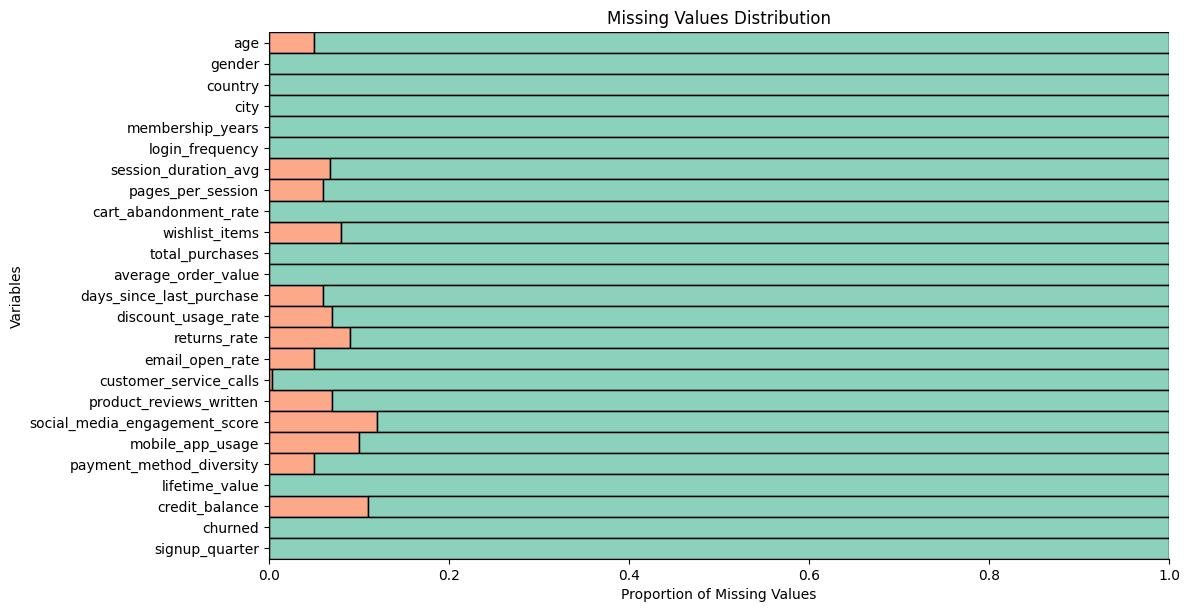

In [44]:
dfna = df.isnull().melt()
dfna.columns = ['variable', 'value']

sns.displot(
    data=dfna,
    y='variable',
    hue='value',
    multiple='fill',
    aspect=2,
    height=6,
    palette='Set2',
    legend=False
)

plt.title('Missing Values Distribution')
plt.xlabel('Proportion of Missing Values')
plt.ylabel('Variables')
plt.show()

**Estrategias para rellenar nulos**

Se realizó un tratamiento de valores nulos utilizando distintos criterios según la naturaleza de cada variable. En variables numéricas con posible presencia de valores atípicos o distribuciones sesgadas, se optó por la imputación con la mediana, dado que es una medida robusta frente a outliers.



**Age (Edad del cliente):** se imputa con la mediana, por su robustez ante valores extremos.

**Session_Duration_Avg (Duración promedio de la sesión)**: se completa con la mediana, debido a su posible sesgo.

**Pages_Per_Session (Páginas vistas por sesión):** se imputa con la mediana, ya que puede presentar distribución asimétrica.

**Wishlist_Items (Productos en lista de deseos):** se utiliza la mediana, considerando la presencia de outliers (usuarios con muchos productos).

**Days_Since_Last_Purchase (Días desde la última compra):** se completa con la mediana por su posible sesgo.

**Discount_Usage_Rate (Uso de descuentos):** se imputa con la mediana, por tratarse de una variable potencialmente sesgada.

**Social_Media_Engagement_Score (Interacción en redes):** se completa con la mediana, por la presencia de asimetrías.

**Payment_Method_Diversity (Cantidad de métodos de pago):** se imputa con la mediana.

**Credit_Balance (Saldo de crédito):** se utiliza la mediana debido a la posible presencia de valores atípicos.



En variables donde la ausencia de datos puede interpretarse como inexistencia de actividad, se optó por imputar con cero:


**Returns_Rate (Tasa de devoluciones)**

**Email_Open_Rate (Tasa de apertura de emails)**

**Product_Reviews_Written (Reseñas escritas)**

**Mobile_App_Usage (Uso de app móvil)**

En estos casos, el valor nulo se interpreta como ausencia de acción (por ejemplo, no devoluciones, no aperturas o no uso).


Por otro lado, en la variable:


**Customer_Service_Calls (Llamadas al servicio al cliente):** se eliminaron las filas con valores nulos, ya que representan una proporción mínima del dataset. Dado el tamaño de los datos, esta decisión no afecta significativamente la calidad ni introduce sesgos relevantes.

Se aplicó imputación por mediana en las variables mencionadas, de acuerdo con los criterios establecidos previamente.

In [45]:
df['age'].fillna(df['age'].median(), inplace=True)
df['session_duration_avg'].fillna(df['session_duration_avg'].median(), inplace=True)
df['pages_per_session'].fillna(df['pages_per_session'].median(), inplace=True)
df['wishlist_items'].fillna(df['wishlist_items'].median(), inplace=True)
df['days_since_last_purchase'].fillna(df['days_since_last_purchase'].median(), inplace=True)
df['discount_usage_rate'].fillna(df['days_since_last_purchase'].median(), inplace=True)
df['customer_service_calls'].fillna(df['customer_service_calls'].median(), inplace=True)
df['social_media_engagement_score'].fillna(df['social_media_engagement_score'].median(), inplace=True)
df['payment_method_diversity'].fillna(df['payment_method_diversity'].median(), inplace=True)
df['credit_balance'].fillna(df['credit_balance'].median(), inplace=True)


/tmp/ipykernel_20719/1560487139.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_20719/1560487139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_20719/1560487139.py:2: FutureWarning: A value is trying to b

Se procede a la eliminación de filas con valores nulos en la variable Customer_Service_Calls, debido a su baja representatividad en el conjunto de datos.

In [46]:
df = df.dropna(subset=['customer_service_calls'])

Se imputan con valor 0 las variables previamente mencionadas.

In [47]:
df['returns_rate'] = df['returns_rate'].fillna(0)
df['email_open_rate'] = df['email_open_rate'].fillna(0)
df['product_reviews_written'] = df['product_reviews_written'].fillna(0)
df['mobile_app_usage'] = df['mobile_app_usage'].fillna(0)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  Int64  
 1   gender                         50000 non-null  object 
 2   country                        50000 non-null  object 
 3   city                           50000 non-null  object 
 4   membership_years               50000 non-null  float64
 5   login_frequency                50000 non-null  Int64  
 6   session_duration_avg           50000 non-null  float64
 7   pages_per_session              50000 non-null  float64
 8   cart_abandonment_rate          50000 non-null  float64
 9   wishlist_items                 50000 non-null  Int64  
 10  total_purchases                50000 non-null  float64
 11  average_order_value            50000 non-null  float64
 12  days_since_last_purchase       50000 non-null 

Análisis de valores únicos en variables categóricas

In [49]:
columnas_categoricas = [
    'gender', 'country', 'city', 'signup_quarter'
]

In [50]:
for columna in columnas_categoricas :
    valores_unicos = df[columna].unique()
    print(f"Valores unicos en'{columna}': '{valores_unicos}")

Valores unicos en'gender': '['Male' 'Female' 'Other']
Valores unicos en'country': '['France' 'UK' 'Canada' 'USA' 'India' 'Japan' 'Germany' 'Australia']
Valores unicos en'city': '['Marseille' 'Manchester' 'Vancouver' 'New York' 'Delhi' 'Tokyo' 'Berlin'
 'Houston' 'Calgary' 'Glasgow' 'Munich' 'Phoenix' 'Paris' 'Ottawa'
 'Los Angeles' 'Bangalore' 'Adelaide' 'Yokohama' 'Sydney' 'Nagoya'
 'Frankfurt' 'Cologne' 'Hamburg' 'Nice' 'Chicago' 'Toulouse' 'Brisbane'
 'Leeds' 'Mumbai' 'Montreal' 'Melbourne' 'Osaka' 'Lyon' 'Hyderabad'
 'Chennai' 'Birmingham' 'London' 'Toronto' 'Perth' 'Kyoto']
Valores unicos en'signup_quarter': '['Q1' 'Q4' 'Q2' 'Q3']


/tmp/ipykernel_20719/300800870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[columna], ax=axes[i], palette='viridis')
/tmp/ipykernel_20719/300800870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[columna], ax=axes[i], palette='viridis')
/tmp/ipykernel_20719/300800870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[columna], ax=axes[i], palette='viridis')
/tmp/ipykernel_20719/300800870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

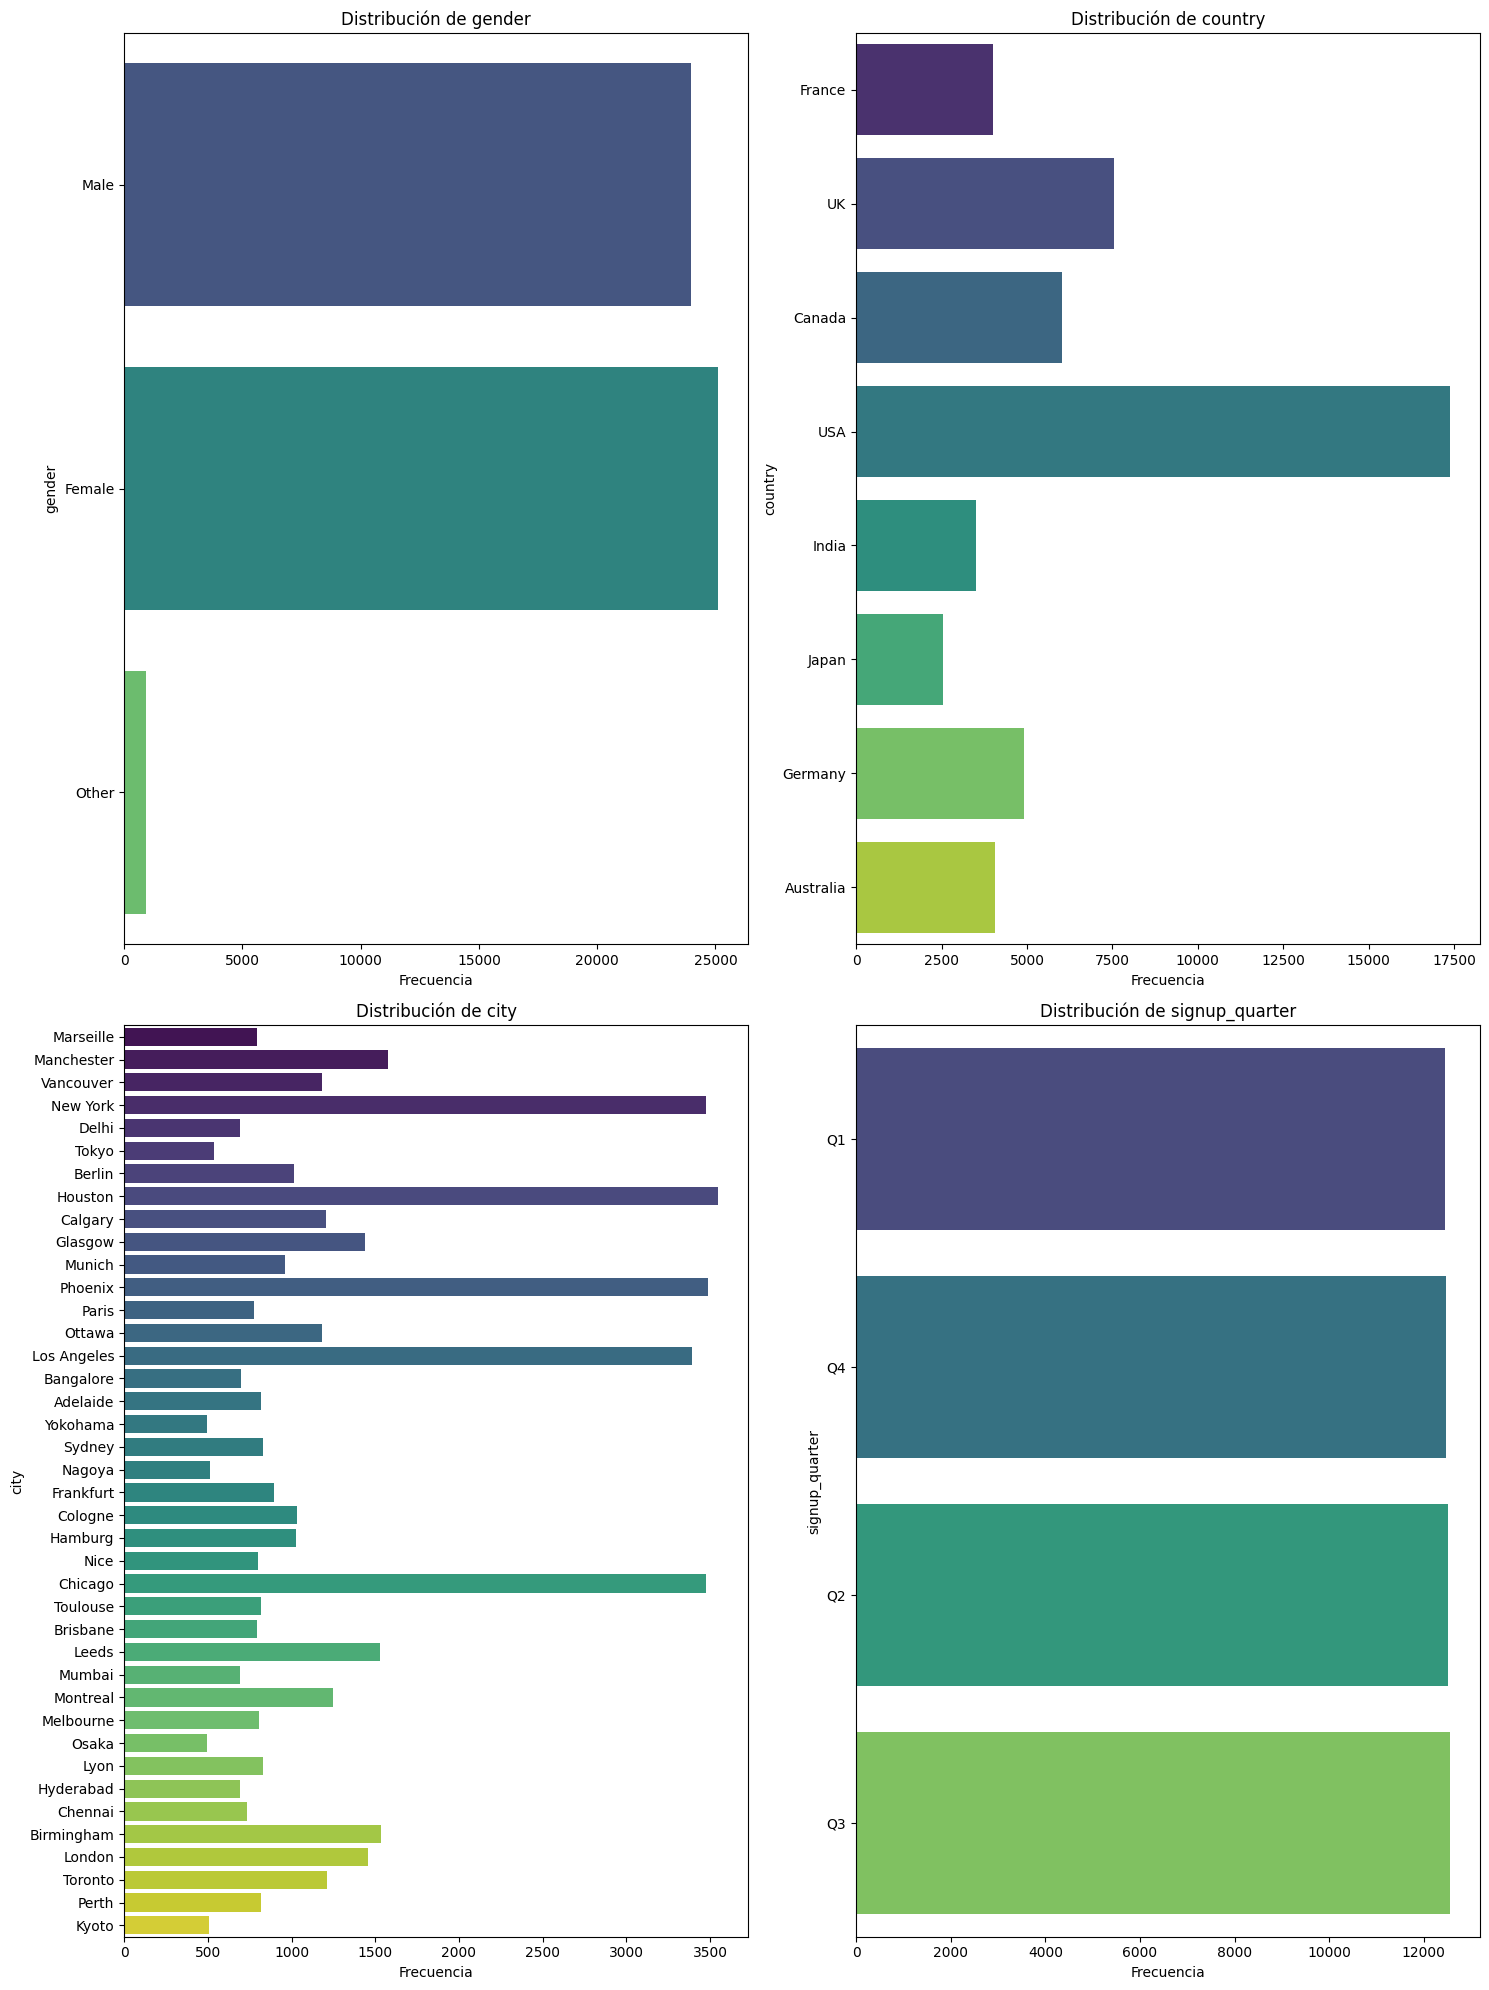

In [51]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, columna in enumerate(columnas_categoricas):
    sns.countplot(y=df[columna], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {columna}')
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel(columna)

plt.tight_layout()

In [52]:
df["signup_quarter"].value_counts()

,count
signup_quarter,
Q3,12558
Q2,12521
Q4,12468
Q1,12453


Se realizó un análisis de los valores únicos en las variables categóricas, observándose que no presentan inconsistencias, errores de tipeo ni categorías duplicadas. Por lo tanto, no fue necesario realizar modificaciones, ya que los valores se encuentran correctamente definidos.

Adicionalmente, al analizar la variable signup_quarter, se observó una distribución visual similar entre los distintos trimestres. A partir de esto, se procedió a cuantificar la cantidad de registros por categoría, con el objetivo de verificar si efectivamente presentaban una distribución equilibrada.

Para validar la distribución observada, se realizó un recuento de frecuencias de la variable, confirmando que los valores se distribuyen de manera equilibrada entre las distintas categorías.

## **Tratamiento de outliers**

In [53]:
columnas_numericas = df.select_dtypes(include='number').columns

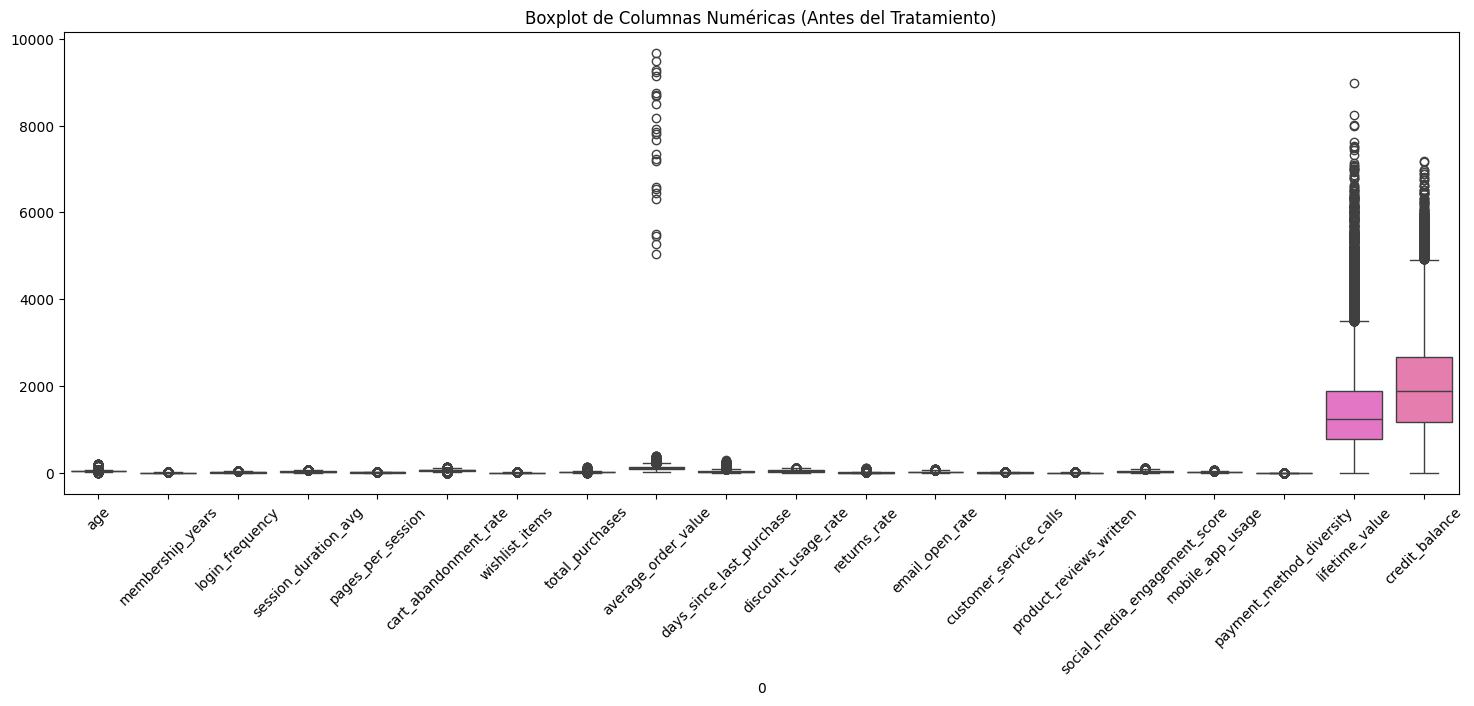

In [54]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[columnas_numericas])
plt.title("Boxplot de Columnas Numéricas (Antes del Tratamiento)")
plt.xticks(rotation=45)
plt.show()

In [55]:

def detectar_outliers(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = columna[(columna < limite_inferior) | (columna > limite_superior)]
    return outliers

for columna in columnas_numericas:
    outliers = detectar_outliers(df[columna])
    print(f"Número de outliers segun IQR en '{columna}': {len(outliers)}")
    print(f"Outliers en '{columna}': {outliers.values}\n")

Número de outliers segun IQR en 'age': 321
Outliers en 'age': <IntegerArray>
[ 70,  75,  74,  68,   5,  69,  68,  68,  68,  69,
 ...
  71,  68,  68,  71,   5, 200,  73,  72,  69,  72]
Length: 321, dtype: Int64

Número de outliers segun IQR en 'membership_years': 1581
Outliers en 'membership_years': [ 9.3  9.1  9.5 ... 10.   8.3 10. ]

Número de outliers segun IQR en 'login_frequency': 309
Outliers en 'login_frequency': <IntegerArray>
[34, 39, 34, 40, 34, 36, 40, 34, 35, 37,
 ...
 38, 34, 39, 34, 39, 35, 34, 37, 35, 34]
Length: 309, dtype: Int64

Número de outliers segun IQR en 'session_duration_avg': 529
Outliers en 'session_duration_avg': [56.2 59.9 66.4 69.1 62.7 61.7 57.3 57.6 56.4 56.3 56.4 56.4 62.7 60.5
 56.7 57.4 56.2 55.5 59.2 57.1 62.1 56.6 56.3 55.7 60.2 56.7 60.5 61.2
 59.7 55.  59.4 55.4 65.3 55.  55.1 66.9 56.  56.2 63.6 63.1 60.3 60.8
 60.  55.7 59.5 66.1 63.1 55.2 62.6 59.1 55.9 64.  66.3 57.7 63.7 56.8
 59.8 56.9 54.9 61.4 56.2 58.2 61.1 65.3 54.8 54.8 62.1 56.3 58.9 62

Se identificó una cantidad significativa de valores atípicos (outliers) mediante el método del rango intercuartílico (IQR). Algunos de estos corresponden a posibles errores de calidad de datos (valores inconsistentes o fuera de rango), mientras que otros reflejan comportamientos reales extremos, como clientes altamente activos o de alto valor.

En este sentido, no todos los outliers deben ser eliminados, sino que su tratamiento debe definirse en función del contexto y la lógica del negocio.

In [56]:
def limpiar_errores(df):
    df = df.copy()


    df = df[(df['age'] >= 18) & (df['age'] <= 100)]


    df = df[df['total_purchases'] >= 0]


    tasas = [
        'cart_abandonment_rate',
        'discount_usage_rate',
        'returns_rate',
        'email_open_rate'
    ]

    for col in tasas:
        df = df[(df[col] >= 0) & (df[col] <= 100)]

    return df

Durante la etapa de limpieza de datos, se corrigieron valores inconsistentes con el objetivo de garantizar la calidad del dataset. En primer lugar, la variable age fue restringida a un rango válido entre 18 y 100 años, eliminando registros fuera de estos límites. Asimismo, la variable total_purchases fue ajustada para considerar únicamente valores positivos.

Por otro lado, las variables de tipo tasa —cart_abandonment_rate, discount_usage_rate, returns_rate y email_open_rate— fueron normalizadas para asegurar que sus valores se encuentren dentro del rango lógico de 0% a 100%.

Estas transformaciones permitieron mejorar la coherencia interna de los datos y aumentar la confiabilidad de los análisis posteriores.

In [57]:
def capear_outliers_iqr(df, columnas):
    df_capped = df.copy()

    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping
        df_capped[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df_capped

In [58]:
columnas_capping = [
    'membership_years',
    'login_frequency',
    'session_duration_avg',
    'pages_per_session',
    'wishlist_items',
    'total_purchases',
    'average_order_value',
    'days_since_last_purchase',
    'returns_rate',
    'customer_service_calls',
    'product_reviews_written',
    'social_media_engagement_score',
    'mobile_app_usage',
    'lifetime_value',
    'credit_balance',
    'cart_abandonment_rate'
]

In [59]:
df[columnas_capping] = df[columnas_capping].astype(float)

In [60]:
df_cap = capear_outliers_iqr(df, columnas_capping)

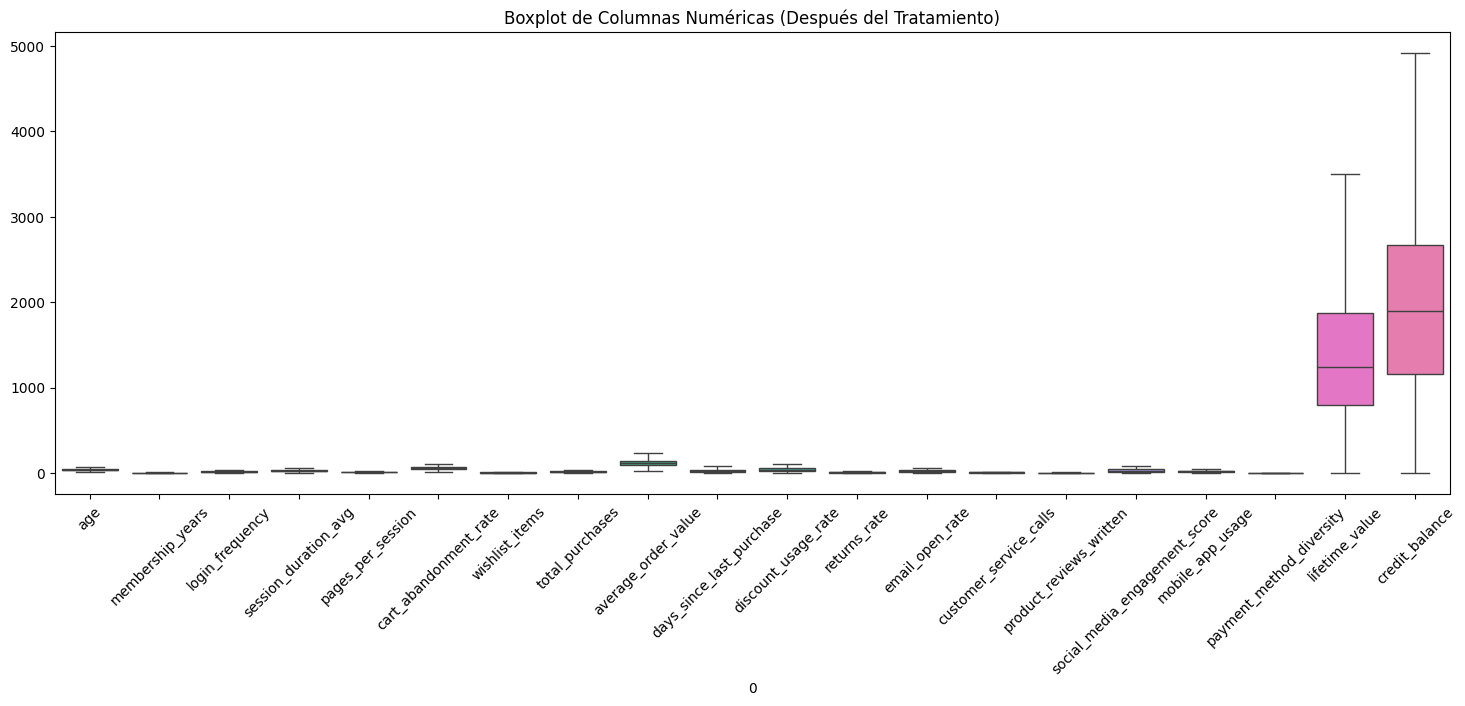

In [61]:
columnas_numericas = df_cap.select_dtypes(include='number').columns

plt.figure(figsize=(18, 6))
sns.boxplot(data=df_cap[columnas_numericas], showfliers=False)
plt.title("Boxplot de Columnas Numéricas (Después del Tratamiento)")
plt.xticks(rotation=45)
plt.show()

Finalmente, se aplicó la técnica de capping para el tratamiento de valores atípicos, utilizando los límites definidos por el método del rango intercuartílico (IQR). Esta técnica permitió acotar los valores extremos sin eliminar registros, preservando así la información del dataset.

Su aplicación resultó especialmente útil en variables donde los outliers podían representar tanto errores como comportamientos reales, logrando reducir su impacto sin afectar la estructura general de los datos.

# **Analisis exploratorio de datos (EDA)**

### **Analisis Univariado**

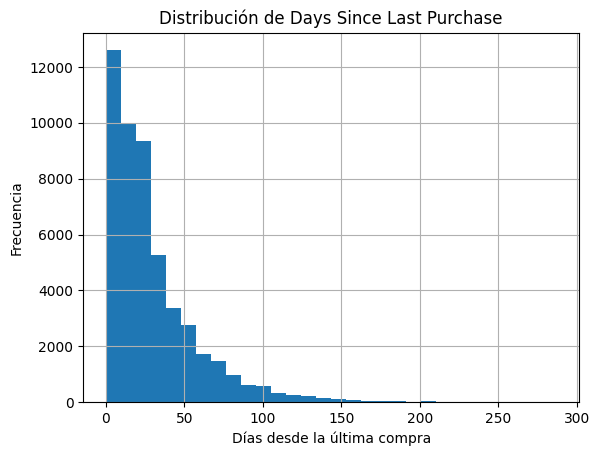

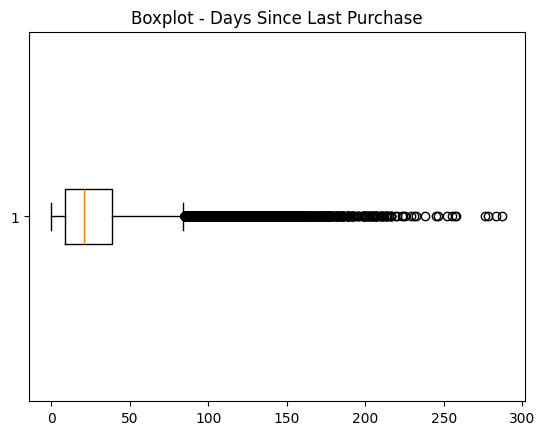

count    50000.000000
mean        29.265300
std         28.866043
min          0.000000
25%          9.000000
50%         21.000000
75%         39.000000
max        287.000000
Name: days_since_last_purchase, dtype: float64


In [62]:
col = 'days_since_last_purchase'

plt.figure()
df[col].hist(bins=30)
plt.title('Distribución de Days Since Last Purchase')
plt.xlabel('Días desde la última compra')
plt.ylabel('Frecuencia')
plt.show()

plt.figure()
plt.boxplot(df[col], vert=False)
plt.title('Boxplot - Days Since Last Purchase')
plt.show()

print(df[col].describe())

La variable days_since_last_purchase presenta una distribución fuertemente sesgada a la derecha, con una alta concentración de clientes que realizaron compras recientemente y una menor proporción con valores elevados.

La diferencia entre la media y la mediana refuerza la presencia de este sesgo, mientras que el boxplot evidencia una gran cantidad de valores atípicos hacia la derecha, correspondientes a clientes que no han realizado compras en un período prolongado.

Desde una perspectiva de negocio, estos valores elevados resultan especialmente relevantes, ya que pueden indicar clientes con mayor probabilidad de abandono (churn), convirtiendo a esta variable en un fuerte predictor del comportamiento del cliente.

### **Analisis Bivariado**

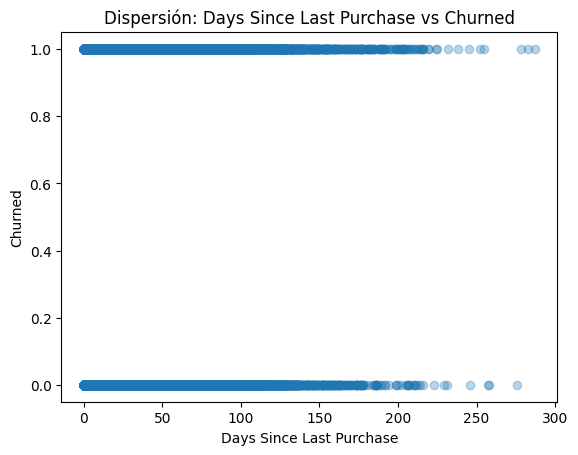

In [63]:
plt.figure()
plt.scatter(df['days_since_last_purchase'], df['churned'], alpha=0.3)

plt.xlabel('Days Since Last Purchase')
plt.ylabel('Churned')
plt.title('Dispersión: Days Since Last Purchase vs Churned')

plt.show()

El gráfico de dispersión muestra la relación entre days_since_last_purchase y churn. Dado que la variable objetivo es binaria, los valores se agrupan en dos niveles (0 y 1), lo que limita la capacidad interpretativa del gráfico.

Sin embargo, se observa que a medida que aumentan los días desde la última compra, crece la presencia de clientes que presentan churn, lo que sugiere una posible relación positiva entre ambas variables.

1 → Cliente que abandona

0 → Cliente que permanece activo

Debido a esta limitación, se recurre a visualizaciones complementarias como boxplots y medidas agregadas, que permiten comparar de manera más clara las diferencias entre ambos grupos.

In [64]:
df.groupby('churned')['days_since_last_purchase'].mean().rename({
    0: 'No Churn',
    1: 'Churn'
})

,days_since_last_purchase
churned,
No Churn,26.541322
Churn,35.966851


<Figure size 640x480 with 0 Axes>

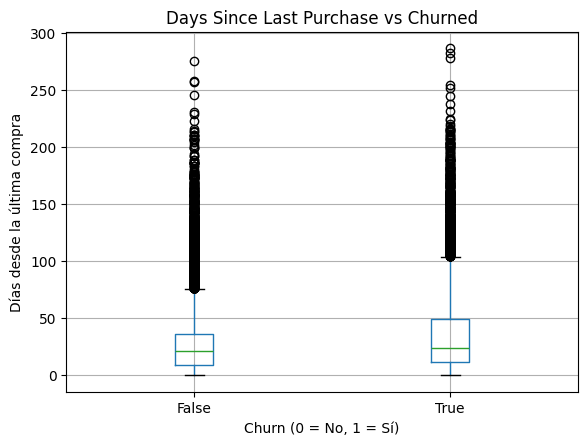

In [65]:
plt.figure()
df.boxplot(column='days_since_last_purchase', by='churned')

plt.title('Days Since Last Purchase vs Churned')
plt.suptitle('')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Días desde la última compra')

plt.show()

Se analizó la relación entre days_since_last_purchase y la variable objetivo churn mediante un boxplot. Se observa que los clientes que presentan churn tienen, en promedio, una mayor cantidad de días desde su última compra en comparación con aquellos que no abandonan.

Asimismo, la distribución del grupo churn se encuentra desplazada hacia valores más altos, lo que indica una mayor inactividad. La presencia de valores atípicos en ambos grupos refleja la existencia de clientes con comportamientos extremos, especialmente aquellos que no han realizado compras en largos períodos.

Estos resultados sugieren que el tiempo desde la última compra es un factor relevante en la predicción del churn.

In [66]:
df.groupby('churned')['customer_service_calls'].mean().rename({
    0: 'No Churn',
    1: 'Churn'
})

,customer_service_calls
churned,
No Churn,5.184895
Churn,6.896471


<Figure size 640x480 with 0 Axes>

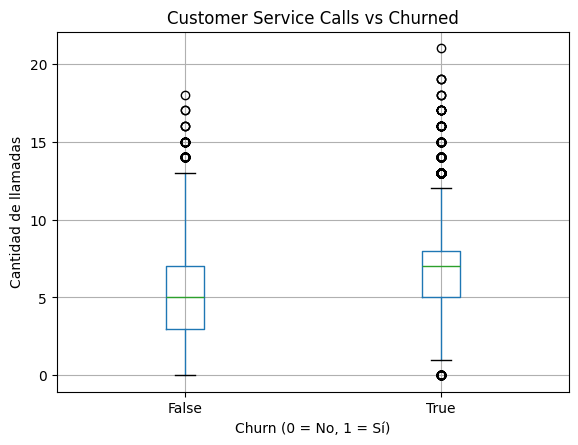

In [67]:
plt.figure()
df.boxplot(column='customer_service_calls', by='churned')

plt.title('Customer Service Calls vs Churned')
plt.suptitle('')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de llamadas')

plt.show()

Se analizó la relación entre customer_service_calls y la variable objetivo churn mediante un boxplot. Se observa que los clientes que presentan churn registran, en promedio, una mayor cantidad de llamadas al servicio al cliente en comparación con aquellos que no abandonan.

La distribución del grupo churn se encuentra desplazada hacia valores más altos, lo que sugiere una mayor frecuencia de interacción con el servicio de atención. Asimismo, la presencia de valores atípicos indica la existencia de clientes con un número elevado de reclamos.

Estos resultados sugieren que una mayor cantidad de contactos con el servicio al cliente puede estar asociada a problemas o insatisfacción, incrementando la probabilidad de abandono.

In [68]:
df.groupby('churned')['total_purchases'].mean().rename({
    0: 'No Churn',
    1: 'Churn'
})

,total_purchases
churned,
No Churn,13.827522
Churn,11.350201


<Figure size 640x480 with 0 Axes>

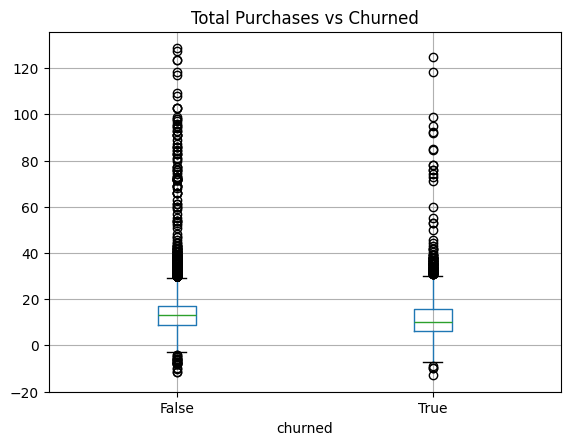

In [69]:
plt.figure()
df.boxplot(column='total_purchases', by='churned')
plt.title('Total Purchases vs Churned')
plt.suptitle('')
plt.show()

Se analizó la relación entre total_purchases y la variable objetivo churn. Se observa que los clientes que presentan churn tienen, en promedio, una menor cantidad de compras en comparación con aquellos que no abandonan.

La distribución del grupo churn se encuentra levemente desplazada hacia valores más bajos, lo que sugiere un menor nivel de actividad o engagement. Sin embargo, la superposición entre ambos grupos indica que esta variable, si bien relevante, no resulta suficiente por sí sola para explicar el comportamiento de abandono.

Estos resultados sugieren que el nivel de actividad del cliente es un factor importante, aunque debe analizarse en conjunto con otras variables.

### **Analisis Multivariado**

Como la cantidad de variables de mi dataset es muy elevada voy a establecer un umbral para que aquellas que tengan una correlaccion menos a 0.15 no se muestren en la matriz. Este procedimiento se realiza antes de graficar la matriz de correlación para que el grafico quede claro.

In [72]:
correlacion =df.corr(numeric_only=True)

In [76]:
umbral = 0.15
correlaciones_target = abs(correlacion['churned']).sort_values(ascending=False)
columnas_a_mantener = correlaciones_target[correlaciones_target >= umbral].index.tolist()

matriz_filtrada = correlacion.loc[columnas_a_mantener, columnas_a_mantener]

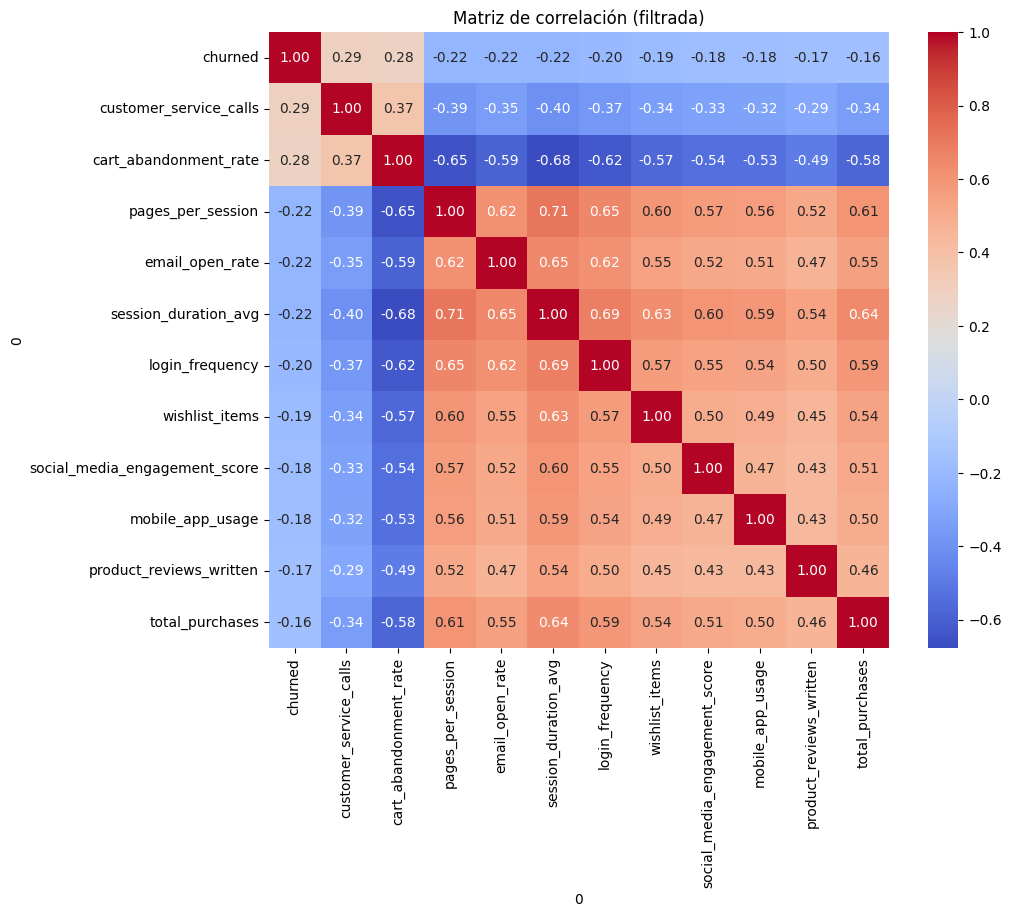

In [77]:
plt.figure(figsize=(10,8))

sns.heatmap(matriz_filtrada, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Matriz de correlación (filtrada)")
plt.show()

El análisis de correlación permitió identificar las variables más relacionadas con el churn. Se observa que variables como customer_service_calls y cart_abandonment_rate presentan una correlación positiva con la variable objetivo, lo que sugiere que un mayor nivel de fricción en la experiencia del cliente está asociado a una mayor probabilidad de abandono.

Por otro lado, variables vinculadas al engagement del usuario, como session_duration_avg, pages_per_session y login_frequency, presentan correlaciones negativas con el churn, indicando que un mayor nivel de interacción reduce la probabilidad de abandono.

Asimismo, se observa una alta correlación entre múltiples variables de comportamiento, lo que evidencia la presencia de multicolinealidad y sugiere que varias de ellas capturan dimensiones similares del engagement del cliente.

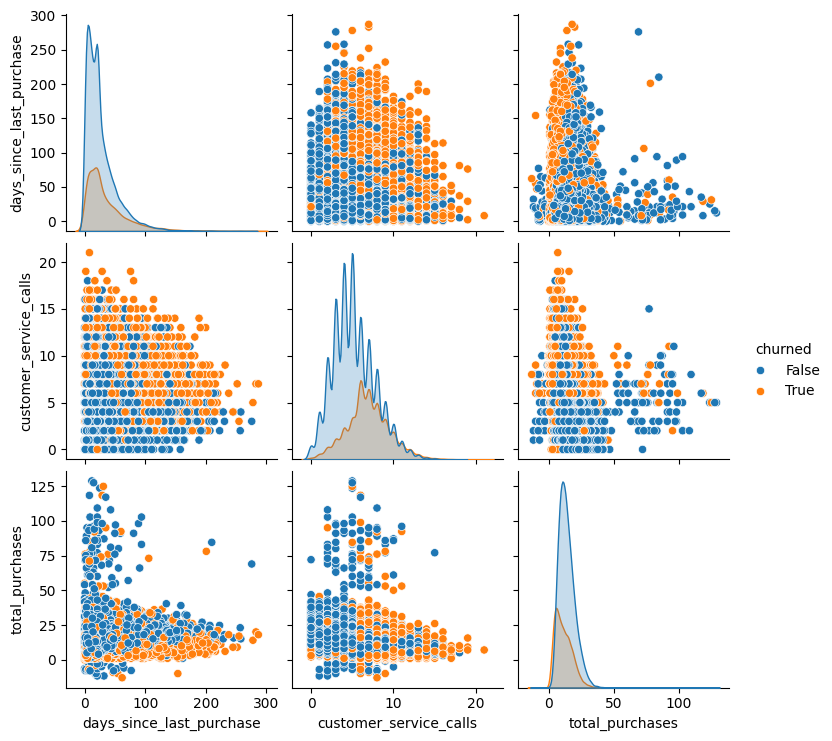

In [78]:
sns.pairplot(df[['days_since_last_purchase',
                 'customer_service_calls',
                 'total_purchases',
                 'churned']],
             hue='churned')

plt.show()

Para el análisis multivariado se seleccionó un subconjunto de variables relevantes en función de su relación con la variable objetivo (churned) y su interpretación desde el punto de vista del negocio. En particular, se eligieron variables que representan distintas dimensiones del comportamiento del cliente, como la inactividad (days_since_last_purchase), la interacción con el servicio (customer_service_calls) y el nivel de actividad (total_purchases).

Esta selección permitió reducir la complejidad visual del análisis y enfocarse en los factores más influyentes en el abandono de clientes.

El análisis multivariado mediante pairplot permitió visualizar la relación conjunta entre variables clave y su comportamiento en función del churn. Se observa que los clientes que abandonan tienden a concentrarse en regiones caracterizadas por mayor inactividad, menor cantidad de compras y mayor número de interacciones con el servicio al cliente.

Asimismo, se identifican relaciones entre las variables, como la asociación inversa entre la cantidad de compras y los días desde la última compra. Sin embargo, la superposición entre clientes con y sin churn evidencia que el abandono es un fenómeno multifactorial, que no puede explicarse a partir de una única variable.